24BAD050 JOHIYA SRI S
   userId  movieId  rating                        title
0       1        1     4.0             Toy Story (1995)
1       1        3     4.0      Grumpier Old Men (1995)
2       1        6     4.0                  Heat (1995)
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)
4       1       50     5.0   Usual Suspects, The (1995)
SVD RMSE: 0.7446461161082678
SVD MAE: 0.5284173251396765


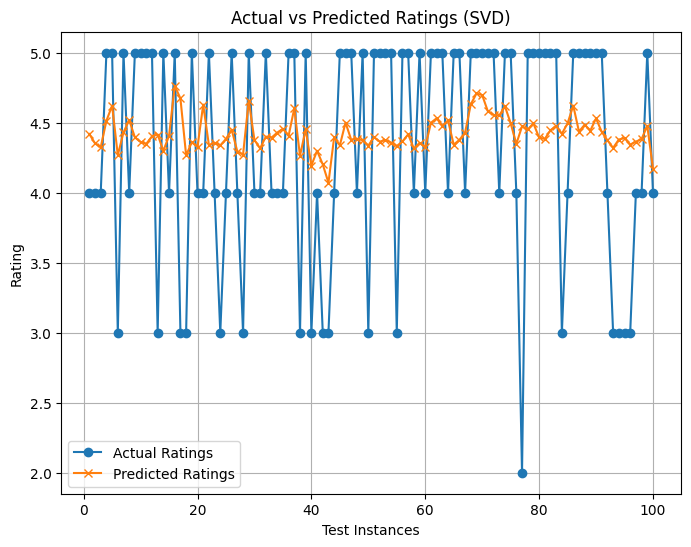

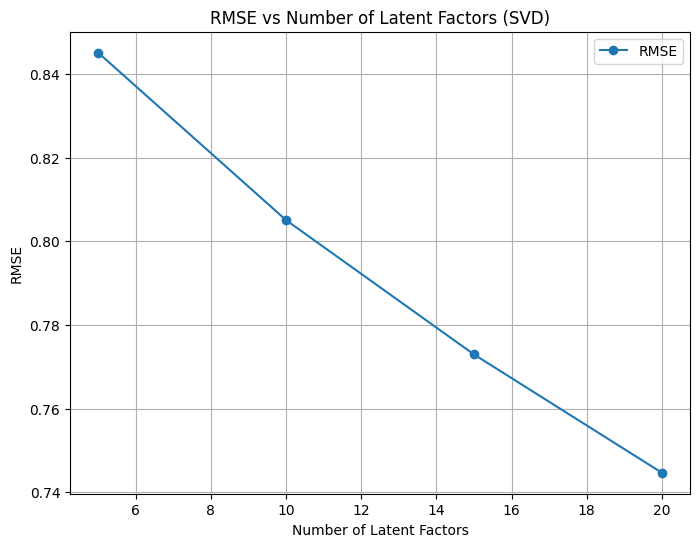

NMF RMSE: 2.4588660650487144
NMF MAE: 2.0419571051773895

Top 10 Recommended Movies for User 1
                                    title  Predicted Rating
0       Terminator 2: Judgment Day (1991)          4.459315
1                           Aliens (1986)          4.413284
2                 Sixth Sense, The (1999)          3.321672
3  Star Trek II: The Wrath of Khan (1982)          3.229055
4                         Die Hard (1988)          3.200490
5                     Blade Runner (1982)          3.168123
6                      Stand by Me (1986)          3.158583
7              Breakfast Club, The (1985)          3.063025
8         Star Trek: First Contact (1996)          2.911578
9        Hunt for Red October, The (1990)          2.901690


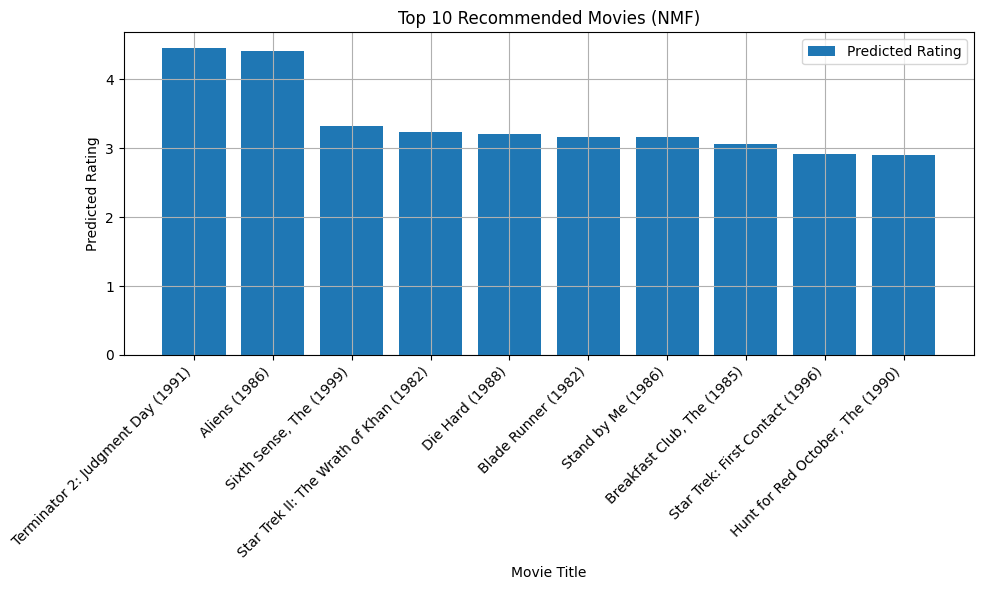

In [1]:
print("24BAD050 JOHIYA SRI S")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds
from sklearn.decomposition import NMF

ratings = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\ratings.csv\ratings.csv")
movies = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\movies.csv")

ratings = ratings[['userId', 'movieId', 'rating']]
movies = movies[['movieId', 'title']]

df = pd.merge(ratings, movies, on='movieId')

print(df.head())

user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

mean_user_rating = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(mean_user_rating, axis=0)
matrix_norm = matrix_norm.fillna(0).astype(float)

k = min(20, min(matrix_norm.shape) - 1)

U, sigma, Vt = svds(matrix_norm.values, k=k)
sigma = np.diag(sigma)

reconstructed_matrix = np.dot(np.dot(U, sigma), Vt)
reconstructed_matrix = reconstructed_matrix + mean_user_rating.values.reshape(-1, 1)

predictions = pd.DataFrame(reconstructed_matrix, index=user_item_matrix.index, columns=user_item_matrix.columns)

mask = ~user_item_matrix.isna().values

actual = user_item_matrix.values[mask]
pred = predictions.values[mask]

rmse_value = np.sqrt(mean_squared_error(actual, pred))
mae_value = mean_absolute_error(actual, pred)

print("SVD RMSE:", rmse_value)
print("SVD MAE:", mae_value)

actual_ratings = actual[:100]
predicted_ratings = pred[:100]

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(actual_ratings) + 1), actual_ratings, marker='o', label='Actual Ratings')
plt.plot(range(1, len(predicted_ratings) + 1), predicted_ratings, marker='x', label='Predicted Ratings')
plt.title("Actual vs Predicted Ratings (SVD)")
plt.xlabel("Test Instances")
plt.ylabel("Rating")
plt.legend()
plt.grid(True)
plt.show()

factor_values = [5, 10, 15, k]
rmse_scores = []

for val in factor_values:
    U, sigma, Vt = svds(matrix_norm.values, k=val)
    sigma = np.diag(sigma)

    recon = np.dot(np.dot(U, sigma), Vt)
    recon = recon + mean_user_rating.values.reshape(-1, 1)

    rmse_k = np.sqrt(mean_squared_error(
        user_item_matrix.values[mask],
        recon[mask]
    ))

    rmse_scores.append(rmse_k)

plt.figure(figsize=(8, 6))
plt.plot(factor_values, rmse_scores, marker='o', label='RMSE')
plt.title("RMSE vs Number of Latent Factors (SVD)")
plt.xlabel("Number of Latent Factors")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

nmf_matrix = user_item_matrix.fillna(0).astype(float)

model = NMF(n_components=20, init='random', random_state=42, max_iter=200)

W = model.fit_transform(nmf_matrix)
H = model.components_

nmf_reconstructed = np.dot(W, H)

nmf_predictions = pd.DataFrame(nmf_reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

rmse_nmf = np.sqrt(mean_squared_error(
    user_item_matrix.values[mask],
    nmf_predictions.values[mask]
))

mae_nmf = mean_absolute_error(
    user_item_matrix.values[mask],
    nmf_predictions.values[mask]
)

print("NMF RMSE:", rmse_nmf)
print("NMF MAE:", mae_nmf)

user_id = 1

all_movie_ids = df['movieId'].unique()
rated_movie_ids = df[df['userId'] == user_id]['movieId'].unique()
unrated_movie_ids = [movie_id for movie_id in all_movie_ids if movie_id not in rated_movie_ids]

recommendations = []
for movie_id in unrated_movie_ids:
    if movie_id in nmf_predictions.columns:
        predicted_rating = nmf_predictions.loc[user_id, movie_id]
        recommendations.append((movie_id, predicted_rating))

recommendations = sorted(recommendations, key=lambda x: x[1], reverse=True)[:10]

recommended_movies = pd.DataFrame(recommendations, columns=['movieId', 'Predicted Rating'])
recommended_movies = recommended_movies.merge(movies, on='movieId')

print("\nTop 10 Recommended Movies for User", user_id)
print(recommended_movies[['title', 'Predicted Rating']])

plt.figure(figsize=(10, 6))
plt.bar(recommended_movies['title'], recommended_movies['Predicted Rating'], label='Predicted Rating')
plt.title("Top 10 Recommended Movies (NMF)")
plt.xlabel("Movie Title")
plt.ylabel("Predicted Rating")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

24BAD050-JOHIYA SRI S


c:\Users\Sibiya Shri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 2.4683
Precision@10: 0.5385878489326765
Recall@10: 0.10935009244706992


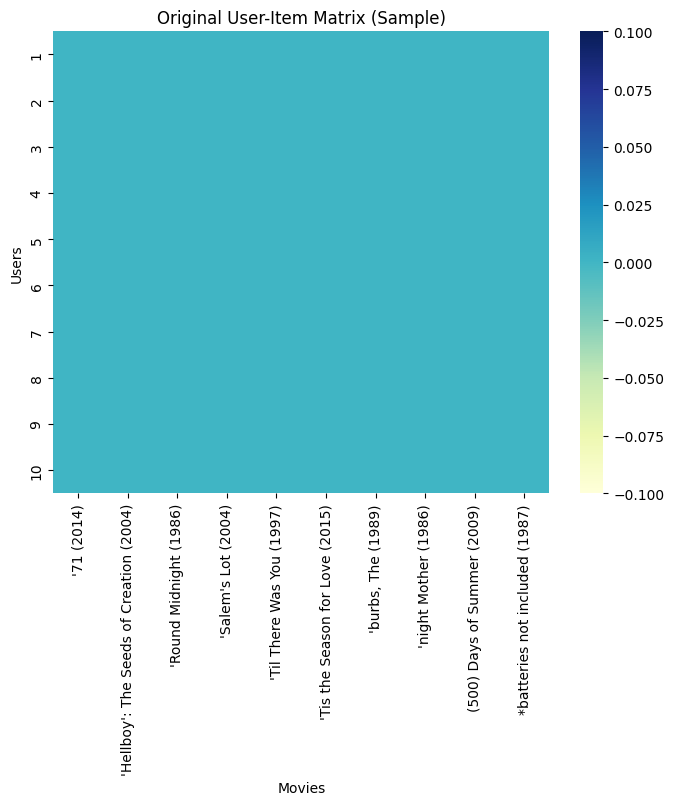

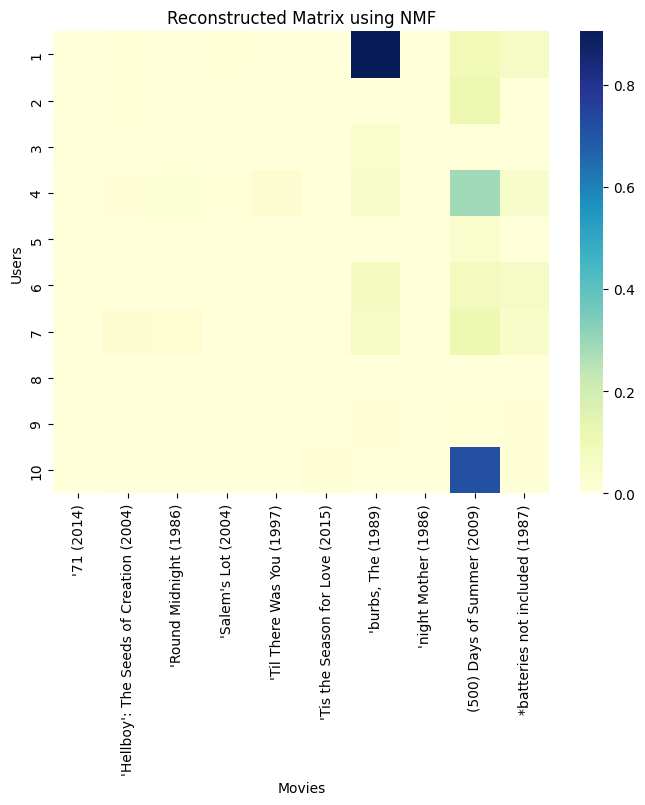

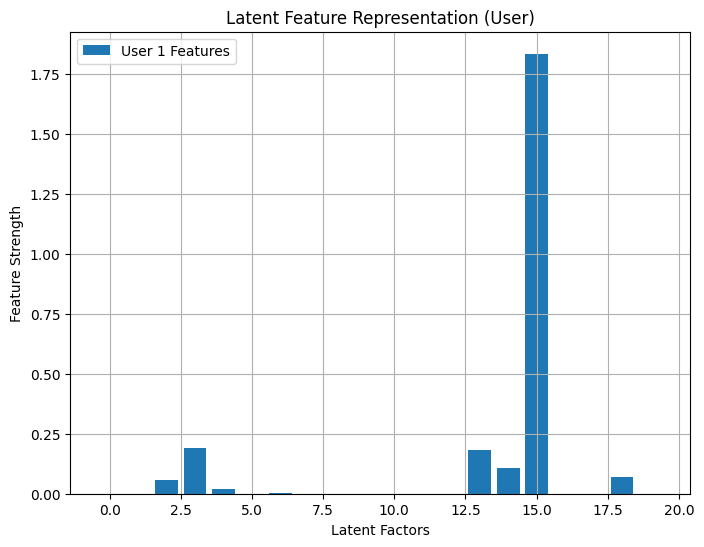


Top 10 Recommended Movies for User 1
title
Terminator 2: Judgment Day (1991)         4.199683
Aliens (1986)                             4.164641
Star Trek II: The Wrath of Khan (1982)    3.371980
Stand by Me (1986)                        3.297203
Sixth Sense, The (1999)                   3.232429
Die Hard (1988)                           3.175685
Breakfast Club, The (1985)                2.992693
Star Trek: First Contact (1996)           2.973466
Godfather, The (1972)                     2.808179
Star Trek IV: The Voyage Home (1986)      2.724813
Name: 1, dtype: float64


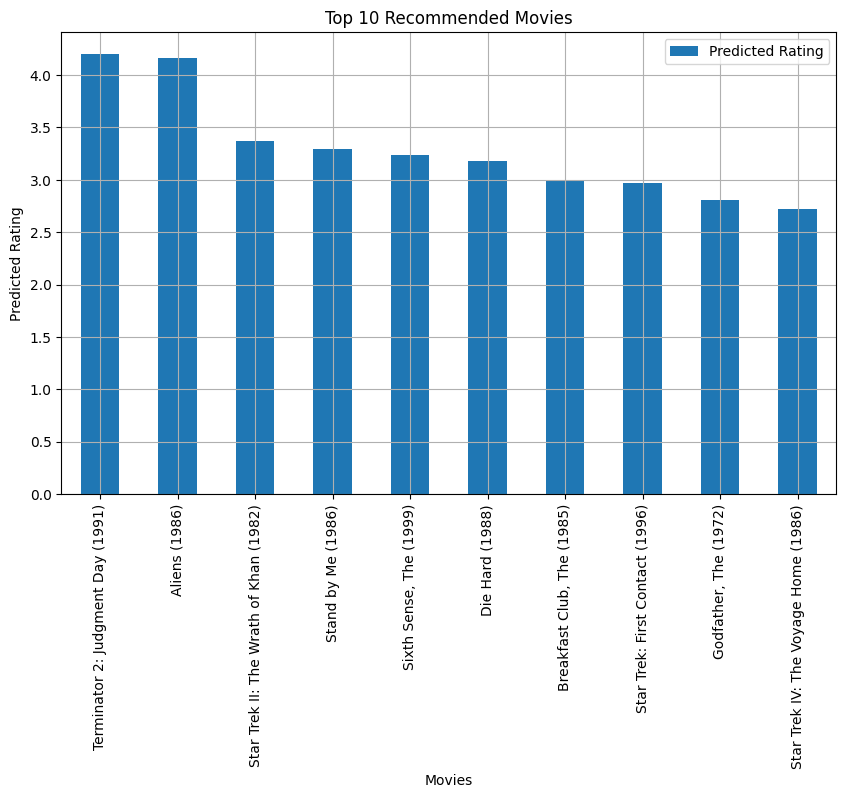

In [1]:
print("24BAD050-JOHIYA SRI S")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import seaborn as sns

ratings = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\ratings.csv\ratings.csv")
movies = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\movies.csv")

ratings = ratings[['userId', 'movieId', 'rating']]
movies = movies[['movieId', 'title']]

df = pd.merge(ratings, movies, on='movieId')

original_matrix = df.pivot_table(index='userId',
                                 columns='title',
                                 values='rating')

user_item_matrix = original_matrix.fillna(0)

matrix = user_item_matrix.values

k = 20

nmf = NMF(n_components=k, init='nndsvda', random_state=42, max_iter=500)
W = nmf.fit_transform(matrix)
H = nmf.components_

matrix_reconstructed = np.dot(W, H)

predicted_df = pd.DataFrame(matrix_reconstructed,
                            index=user_item_matrix.index,
                            columns=user_item_matrix.columns)

mask = matrix != 0
actual = matrix[mask]
predicted = matrix_reconstructed[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f"RMSE: {rmse:.4f}")

def precision_recall_at_k(pred_df, original_matrix, k=10, threshold=3.5):
    precisions = []
    recalls = []

    for user in pred_df.index:
        user_actual = original_matrix.loc[user]
        user_pred = pred_df.loc[user]

        relevant_items = set(user_actual[user_actual >= threshold].index)

        if len(relevant_items) == 0:
            continue

        top_k_items = set(user_pred.sort_values(ascending=False).head(k).index)

        true_positives = len(top_k_items & relevant_items)

        precision = true_positives / k
        recall = true_positives / len(relevant_items)

        precisions.append(precision)
        recalls.append(recall)

    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0

    return avg_precision, avg_recall

precision_k, recall_k = precision_recall_at_k(predicted_df, original_matrix, k=10, threshold=3.5)

print("Precision@10:", precision_k)
print("Recall@10:", recall_k)

plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.iloc[:10, :10], cmap='YlGnBu')
plt.title("Original User-Item Matrix (Sample)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(predicted_df.iloc[:10, :10], cmap='YlGnBu')
plt.title("Reconstructed Matrix using NMF")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

plt.figure(figsize=(8,6))
plt.bar(range(k), W[0], label='User 1 Features')
plt.title("Latent Feature Representation (User)")
plt.xlabel("Latent Factors")
plt.ylabel("Feature Strength")
plt.legend()
plt.grid(True)
plt.show()

user_id = 1

if user_id in predicted_df.index:
    user_ratings = predicted_df.loc[user_id]
    original_user = original_matrix.loc[user_id]

    recommendations = user_ratings[original_user.isna()].sort_values(ascending=False)

    top_n = recommendations.head(10)

    print("\nTop 10 Recommended Movies for User", user_id)
    print(top_n)

    plt.figure(figsize=(10,6))
    top_n.plot(kind='bar', label='Predicted Rating')
    plt.title("Top 10 Recommended Movies")
    plt.xlabel("Movies")
    plt.ylabel("Predicted Rating")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("User not found")